# Phase 9 — Anomaly Detection

## 9.8 Anomaly-Detection Problem Definition

### Business Problem

Traditional reporting identifies operational issues after aggregating transaction outcomes. The anomaly-detection component aims to identify individual transactions whose characteristics differ substantially from normal UPI transaction behaviour.

### Analytical Question

Can the platform identify unusual transactions based on amount, transaction context, banking attributes, customer groups, location, device, network and transaction time?

### Machine-Learning Task

This is an unsupervised anomaly-detection problem.

Unlike failure prediction, the algorithm is not trained using known success, failure or fraud outcomes. It learns the general structure of transaction behaviour and assigns a higher anomaly score to unusual observations.

### Intended Business Use

The anomaly scores may support:

- Operational investigation prioritisation
- Identification of unusual transaction amounts
- Detection of rare transaction-context combinations
- Monitoring of unusual bank, device or network behaviour
- Additional risk indicators for dashboards and review queues

### Important Interpretation

An anomalous transaction is not automatically fraudulent or failed.

An anomaly means only that the transaction differs from typical behaviour represented in the dataset. Every flagged transaction requires contextual investigation before any business action is taken.

### Validation Approach

After generating anomaly scores, the anomaly groups will be compared with `transaction_status` and `fraud_flag`.

These outcome columns will be used only for retrospective validation and profiling—not for training the anomaly-detection model.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

RANDOM_STATE = 42

In [2]:
# Load the processed dataset
data_path = Path(
    "../data/processed/upi_transactions_processed.csv"
)

df = pd.read_csv(
    data_path,
    parse_dates=["timestamp"]
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Duplicate transaction IDs: {df['transaction_id'].duplicated().sum():,}")
print(f"Timestamp type: {df['timestamp'].dtype}")

df.head()

Rows: 250,000
Columns: 17
Missing values: 0
Duplicate transaction IDs: 0
Timestamp type: datetime64[ns]


,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


## 9.9 Anomaly Feature Selection

The anomaly model uses transaction attributes that describe behaviour available at transaction initiation.

The following outcome columns are excluded from model training:

- `transaction_status`
- `fraud_flag`

These are retained separately for retrospective validation.

`transaction_id` is excluded because it is only an identifier. The raw timestamp is replaced by operational time features.

In [3]:
categorical_features = [
    "transaction_type",
    "merchant_category",
    "sender_age_group",
    "receiver_age_group",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type"
]

numerical_features = [
    "log_amount",
    "hour_sin",
    "hour_cos",
    "is_weekend"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print(
    "Total behavioural features:",
    len(categorical_features) + len(numerical_features)
)

Categorical features: 9
Numerical features: 4
Total behavioural features: 13


In [4]:
# Engineer numerical features
anomaly_data = df.copy()

# Reduce the effect of the strongly right-skewed amount distribution
anomaly_data["log_amount"] = np.log1p(
    anomaly_data["amount_inr"]
)

# Represent the circular nature of time:
# hour 23 is close to hour 0
anomaly_data["hour_sin"] = np.sin(
    2 * np.pi * anomaly_data["hour_of_day"] / 24
)

anomaly_data["hour_cos"] = np.cos(
    2 * np.pi * anomaly_data["hour_of_day"] / 24
)

model_features = (
    categorical_features + numerical_features
)

X_anomaly = anomaly_data[model_features].copy()

print("Anomaly feature rows:", f"{X_anomaly.shape[0]:,}")
print("Input feature columns:", X_anomaly.shape[1])
print("Missing feature values:", X_anomaly.isna().sum().sum())

X_anomaly.head()

Anomaly feature rows: 250,000
Input feature columns: 13
Missing feature values: 0


,transaction_type,merchant_category,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,log_amount,hour_sin,hour_cos,is_weekend
0,P2P,Entertainment,26-35,18-25,Delhi,Axis,SBI,Android,4G,6.7673,-0.7071,-0.7071,0
1,P2M,Grocery,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,6.9197,1.0000,0.0000,0
2,P2P,Grocery,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,6.1696,-0.2588,-0.9659,0
3,P2P,Fuel,26-35,26-35,Delhi,ICICI,PNB,Android,5G,7.9320,0.5000,-0.8660,1
4,P2P,Shopping,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,6.8987,-0.9659,0.2588,0


## 9.10 Isolation Forest Training

### Algorithm

Isolation Forest identifies unusual observations by repeatedly separating transactions using randomly selected features and split values.

Transactions that can be isolated with fewer splits are considered more unusual.

### Initial Review Capacity

The model uses a contamination rate of 1%. This means approximately the most unusual 1% of transactions will receive the model's anomaly flag.

This value is an operational review-capacity assumption rather than a claim that exactly 1% of transactions are genuinely abnormal.

### Score Direction

The original Isolation Forest score is lower for more unusual transactions. For easier business interpretation, the score will be reversed so that:

- Higher `anomaly_score` = more unusual
- Lower `anomaly_score` = more typical

In [5]:
# Create the preprocessor
anomaly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

anomaly_preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['transaction_type', 'merchant_category',
                                  'sender_age_group', 'receiver_age_group',
                                  'sender_state', 'sender_bank',
                                  'receiver_bank', 'device_type',
                                  'network_type']),
                                ('numerical', StandardScaler(),
                                 ['log_amount', 'hour_sin', 'hour_cos',
                                  'is_weekend'])])

In [6]:
# Create the Isolation Forest pipeline
isolation_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            anomaly_preprocessor
        ),
        (
            "model",
            IsolationForest(
                n_estimators=200,
                max_samples=10000,
                contamination=0.01,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

isolation_forest_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['transaction_type',
                                                   'merchant_category',
                                                   'sender_age_group',
                                                   'receiver_age_group',
                                                   'sender_state',
                                                   'sender_bank',
                                                   'receiver_bank',
                                                   'device_type',
                                                   'network_type']),
                                                 ('numerical', StandardScaler(),
                                                  ['log_amount', 'hour_sin',
                                                   'hour_cos',
                                                   'is_weekend'])])),
                ('model',
                 IsolationForest(contamination=0.01, max_samples=10000,
                                 n_estimators=200, n_jobs=-1,
                                 random_state=42))])

In [7]:
# Train the model
isolation_forest_pipeline.fit(X_anomaly)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [8]:
# Generate predictions and scores
isolation_labels = isolation_forest_pipeline.predict(
    X_anomaly
)

raw_isolation_scores = (
    isolation_forest_pipeline.score_samples(X_anomaly)
)

anomaly_data["isolation_label"] = isolation_labels

# Reverse the score so a larger value means more unusual
anomaly_data["anomaly_score"] = -raw_isolation_scores

anomaly_data["is_anomaly"] = (
    anomaly_data["isolation_label"] == -1
).astype(int)

print(
    "Unique Isolation Forest labels:",
    sorted(anomaly_data["isolation_label"].unique())
)

print(
    "Flagged anomalies:",
    f"{anomaly_data['is_anomaly'].sum():,}"
)

print(
    "Flagged anomaly percentage:",
    f"{anomaly_data['is_anomaly'].mean() * 100:.2f}%"
)

Unique Isolation Forest labels: [np.int64(-1), np.int64(1)]
Flagged anomalies: 2,500
Flagged anomaly percentage: 1.00%


In [9]:
# Score summary
anomaly_score_summary = (
    anomaly_data["anomaly_score"]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
            0.995
        ]
    )
)

anomaly_score_summary

count   250,000.0000
mean          0.4562
std           0.0203
min           0.3972
50%           0.4544
90%           0.4837
95%           0.4926
99%           0.5094
99.5%         0.5155
max           0.5531
Name: anomaly_score, dtype: float64

In [10]:
# Anomaly count summary
anomaly_count_summary = pd.DataFrame({
    "category": ["Typical", "Anomaly"],
    "transaction_count": [
        int((anomaly_data["is_anomaly"] == 0).sum()),
        int((anomaly_data["is_anomaly"] == 1).sum())
    ]
})

anomaly_count_summary["percentage"] = (
    anomaly_count_summary["transaction_count"]
    / len(anomaly_data)
    * 100
).round(2)

anomaly_count_summary

,category,transaction_count,percentage
0,Typical,247500,99.0000
1,Anomaly,2500,1.0000


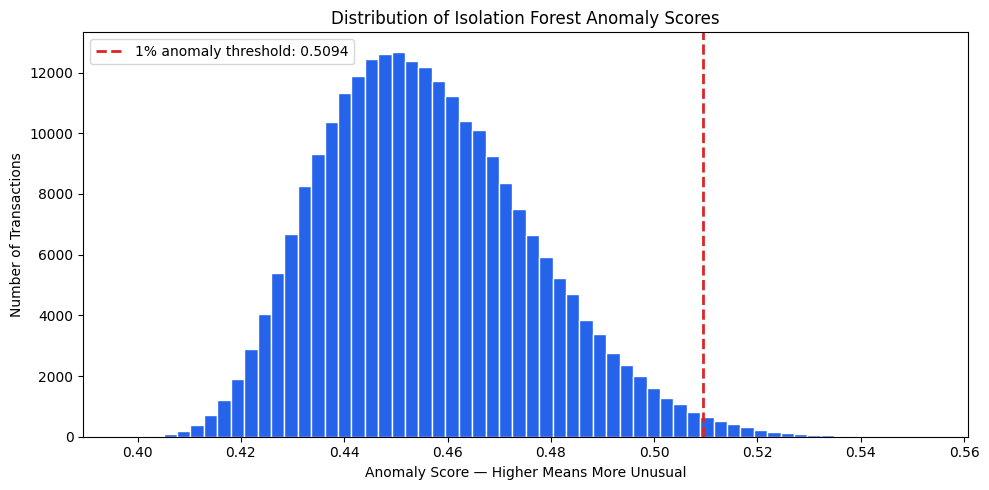

In [11]:
# Visualize score distribution
plt.figure(figsize=(10, 5))

plt.hist(
    anomaly_data["anomaly_score"],
    bins=60,
    color="#2563EB",
    edgecolor="white"
)

anomaly_threshold = anomaly_data.loc[
    anomaly_data["is_anomaly"] == 1,
    "anomaly_score"
].min()

plt.axvline(
    anomaly_threshold,
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label=f"1% anomaly threshold: {anomaly_threshold:.4f}"
)

plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score — Higher Means More Unusual")
plt.ylabel("Number of Transactions")
plt.legend()
plt.tight_layout()
plt.show()

## 9.11 Operational Anomaly Risk Segmentation

### Purpose

A continuous anomaly score is useful for ranking, but operations teams also need understandable review categories.

Transactions are therefore divided into three operational bands:

- **Normal:** transactions below the 95th percentile of anomaly scores
- **Monitor:** transactions within approximately the 95th–99th percentile
- **High Anomaly:** transactions flagged by Isolation Forest as the most unusual 1%

These categories represent investigation priority—not confirmed fraud or failure.

### Expected Review Distribution

- Normal: approximately 95%
- Monitor: approximately 4%
- High Anomaly: approximately 1%

In [12]:
# Calculate thressholda
monitor_threshold = anomaly_data[
    "anomaly_score"
].quantile(0.95)

high_anomaly_threshold = anomaly_data.loc[
    anomaly_data["is_anomaly"] == 1,
    "anomaly_score"
].min()

print(
    f"Monitor threshold: {monitor_threshold:.4f}"
)

print(
    f"High-anomaly threshold: "
    f"{high_anomaly_threshold:.4f}"
)

Monitor threshold: 0.4926
High-anomaly threshold: 0.5094


In [13]:
# Assign risk bands
anomaly_data["anomaly_risk_band"] = np.select(
    [
        anomaly_data["is_anomaly"].eq(1),
        anomaly_data["anomaly_score"].ge(
            monitor_threshold
        )
    ],
    [
        "High Anomaly",
        "Monitor"
    ],
    default="Normal"
)

risk_order = [
    "Normal",
    "Monitor",
    "High Anomaly"
]

anomaly_data["anomaly_risk_band"] = pd.Categorical(
    anomaly_data["anomaly_risk_band"],
    categories=risk_order,
    ordered=True
)

In [14]:
# Risk band distribution
risk_band_summary = (
    anomaly_data
    .groupby(
        "anomaly_risk_band",
        observed=True
    )
    .agg(
        transaction_count=(
            "transaction_id",
            "count"
        ),
        minimum_anomaly_score=(
            "anomaly_score",
            "min"
        ),
        average_anomaly_score=(
            "anomaly_score",
            "mean"
        ),
        maximum_anomaly_score=(
            "anomaly_score",
            "max"
        )
    )
    .reset_index()
)

risk_band_summary["percentage"] = (
    risk_band_summary["transaction_count"]
    / len(anomaly_data)
    * 100
).round(2)

risk_band_summary[
    [
        "anomaly_risk_band",
        "transaction_count",
        "percentage",
        "minimum_anomaly_score",
        "average_anomaly_score",
        "maximum_anomaly_score"
    ]
]

,anomaly_risk_band,transaction_count,percentage,minimum_anomaly_score,average_anomaly_score,maximum_anomaly_score
0,Normal,237500,95.0000,0.3972,0.4538,0.4926
1,Monitor,10000,4.0000,0.4926,0.4992,0.5094
2,High Anomaly,2500,1.0000,0.5094,0.5173,0.5531


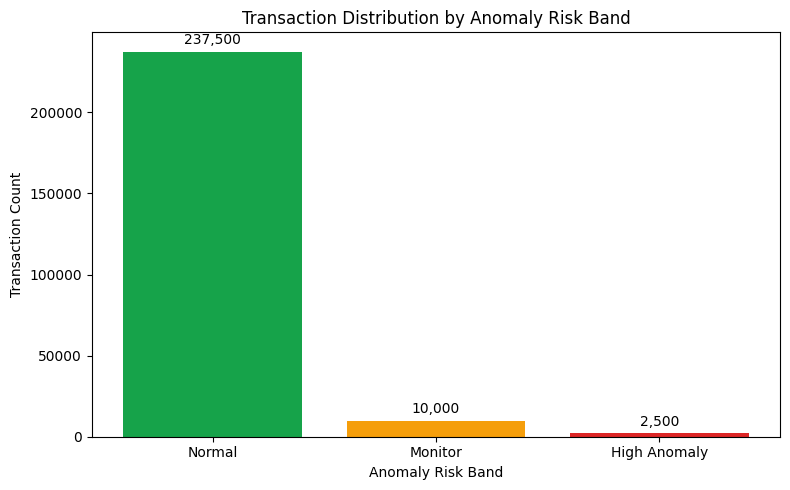

In [15]:
# Visualise risk-band counts
risk_counts = (
    anomaly_data["anomaly_risk_band"]
    .value_counts(sort=False)
)

risk_colors = [
    "#16A34A",
    "#F59E0B",
    "#DC2626"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    risk_counts.index.astype(str),
    risk_counts.values,
    color=risk_colors
)

plt.title("Transaction Distribution by Anomaly Risk Band")
plt.xlabel("Anomaly Risk Band")
plt.ylabel("Transaction Count")

plt.bar_label(
    bars,
    labels=[
        f"{value:,}"
        for value in risk_counts.values
    ],
    padding=3
)

plt.tight_layout()
plt.show()

## 9.12 Retrospective Outcome Validation

### Purpose

The anomaly bands are compared with transaction outcomes to understand whether increasingly unusual transactions also show higher failure or fraud rates.

`transaction_status` and `fraud_flag` were excluded from model training. They are used here only for retrospective validation.

A useful anomaly score may show increasing failure or fraud rates across Normal, Monitor and High-Anomaly groups. However, the absence of such a pattern does not invalidate the detection of unusual behaviour; it means unusualness is not strongly associated with those specific outcomes.

In [16]:
# Profile each risk band
risk_outcome_profile = (
    anomaly_data
    .groupby(
        "anomaly_risk_band",
        observed=True
    )
    .agg(
        total_transactions=(
            "transaction_id",
            "count"
        ),
        average_amount_inr=(
            "amount_inr",
            "mean"
        ),
        median_amount_inr=(
            "amount_inr",
            "median"
        ),
        maximum_amount_inr=(
            "amount_inr",
            "max"
        ),
        failed_transactions=(
            "transaction_status",
            lambda values: (
                values == "FAILED"
            ).sum()
        ),
        fraud_transactions=(
            "fraud_flag",
            "sum"
        )
    )
    .reset_index()
)

risk_outcome_profile[
    "failure_rate_percentage"
] = (
    risk_outcome_profile[
        "failed_transactions"
    ]
    / risk_outcome_profile[
        "total_transactions"
    ]
    * 100
).round(3)

risk_outcome_profile[
    "fraud_rate_percentage"
] = (
    risk_outcome_profile[
        "fraud_transactions"
    ]
    / risk_outcome_profile[
        "total_transactions"
    ]
    * 100
).round(3)

risk_outcome_profile[
    "average_amount_inr"
] = risk_outcome_profile[
    "average_amount_inr"
].round(2)

risk_outcome_profile

,anomaly_risk_band,total_transactions,average_amount_inr,median_amount_inr,maximum_amount_inr,failed_transactions,fraud_transactions,failure_rate_percentage,fraud_rate_percentage
0,Normal,237500,"1,291.5900",627.0000,42099,11750,456,4.9470,0.1920
1,Monitor,10000,"1,668.6600",666.0000,37263,498,21,4.9800,0.2100
2,High Anomaly,2500,"1,799.5600",668.5000,22526,128,3,5.1200,0.1200


### Initial Validation Findings

The anomaly-risk bands show a clear increase in average transaction value. Average value increased from ₹1,291.59 in the Normal group to ₹1,799.56 in the High-Anomaly group.

The failure rate increased slightly from 4.947% for Normal transactions to 5.120% for High-Anomaly transactions. However, this difference is small and does not establish a strong relationship between anomaly status and transaction failure.

The High-Anomaly group recorded a fraud rate of 0.120%, below the overall fraud rate. Therefore, the anomaly score must not be interpreted as a fraud probability.

The results indicate that Isolation Forest is identifying unusual combinations of transaction characteristics rather than reproducing the existing failure or fraud labels.

In [17]:
# Create a reusable profiling function
overall_high_anomaly_rate = (
    anomaly_data["is_anomaly"].mean()
)

def build_anomaly_profile(data, feature):
    profile = (
        data
        .groupby(feature, observed=True)
        .agg(
            total_transactions=(
                "transaction_id",
                "count"
            ),
            high_anomaly_transactions=(
                "is_anomaly",
                "sum"
            ),
            average_anomaly_score=(
                "anomaly_score",
                "mean"
            )
        )
        .reset_index()
    )

    profile["high_anomaly_rate_percentage"] = (
        profile["high_anomaly_transactions"]
        / profile["total_transactions"]
        * 100
    ).round(3)

    profile["anomaly_lift"] = (
        (
            profile["high_anomaly_transactions"]
            / profile["total_transactions"]
        )
        / overall_high_anomaly_rate
    ).round(2)

    profile["dimension"] = feature

    profile = profile.rename(
        columns={feature: "category"}
    )

    return profile[
        [
            "dimension",
            "category",
            "total_transactions",
            "high_anomaly_transactions",
            "high_anomaly_rate_percentage",
            "anomaly_lift",
            "average_anomaly_score"
        ]
    ]

In [24]:
# Profile all categorical dimensions
categorical_profiles = []

for feature in categorical_features:
    feature_profile = build_anomaly_profile(
        anomaly_data,
        feature
    )

    categorical_profiles.append(
        feature_profile
    )

categorical_anomaly_profile = pd.concat(
    categorical_profiles,
    ignore_index=True
)

print(
    "Profiled category rows:",
    len(categorical_anomaly_profile)
)

categorical_anomaly_profile.head()

Profiled category rows: 57


,dimension,category,total_transactions,high_anomaly_transactions,high_anomaly_rate_percentage,anomaly_lift,average_anomaly_score
0,transaction_type,Bill Payment,37368,822,2.2000,2.2000,0.4654
1,transaction_type,P2M,87660,640,0.7300,0.7300,0.4554
2,transaction_type,P2P,112445,435,0.3870,0.3900,0.4518
3,transaction_type,Recharge,12527,603,4.8140,4.8100,0.4752
4,merchant_category,Education,7598,203,2.6720,2.6700,0.4681


In [19]:
# Identify the highest-lift categories
top_anomaly_categories = (
    categorical_anomaly_profile
    .query("total_transactions >= 500")
    .sort_values(
        [
            "dimension",
            "anomaly_lift",
            "high_anomaly_transactions"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .groupby(
        "dimension",
        group_keys=False
    )
    .head(3)
    .reset_index(drop=True)
)

top_anomaly_categories

,dimension,category,total_transactions,high_anomaly_transactions,high_anomaly_rate_percentage,anomaly_lift,average_anomaly_score
0,device_type,Web,12610,1179,9.3500,9.3500,0.4859
1,device_type,iOS,49613,1107,2.2310,2.2300,0.4711
2,device_type,Android,187777,214,0.1140,0.1100,0.4503
3,merchant_category,Education,7598,203,2.6720,2.6700,0.4681
4,merchant_category,Shopping,29872,403,1.3490,1.3500,0.4597
5,merchant_category,Healthcare,12663,171,1.3500,1.3500,0.4605
6,network_type,3G,12471,582,4.6670,4.6700,0.4766
7,network_type,WiFi,25134,1049,4.1740,4.1700,0.4745
8,network_type,5G,62582,530,0.8470,0.8500,0.4610
9,receiver_age_group,56+,12551,537,4.2790,4.2800,0.4735


In [20]:
# View the most anomalous individual transactions
review_columns = [
    "transaction_id",
    "timestamp",
    "transaction_type",
    "merchant_category",
    "amount_inr",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type",
    "hour_of_day",
    "transaction_status",
    "fraud_flag",
    "anomaly_score",
    "anomaly_risk_band"
]

highest_anomaly_transactions = (
    anomaly_data
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    [review_columns]
    .head(20)
    .reset_index(drop=True)
)

highest_anomaly_transactions

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,sender_state,sender_bank,receiver_bank,device_type,network_type,hour_of_day,transaction_status,fraud_flag,anomaly_score,anomaly_risk_band
0,TXN0000074790,2024-06-30 21:57:13,Recharge,Education,1806,Maharashtra,ICICI,Axis,Web,WiFi,21,SUCCESS,0,0.5531,High Anomaly
1,TXN0000178618,2024-04-24 08:37:49,Bill Payment,Shopping,5226,Telangana,Yes Bank,Axis,iOS,WiFi,8,SUCCESS,0,0.5509,High Anomaly
2,TXN0000021818,2024-05-26 17:17:39,P2M,Education,11679,Gujarat,PNB,Kotak,Web,WiFi,17,SUCCESS,0,0.5503,High Anomaly
3,TXN0000149291,2024-04-21 12:43:11,Recharge,Education,7305,Rajasthan,SBI,SBI,Web,WiFi,12,SUCCESS,0,0.5489,High Anomaly
4,TXN0000074642,2024-05-31 03:06:59,Recharge,Grocery,2437,Andhra Pradesh,ICICI,Axis,Web,3G,3,SUCCESS,0,0.5472,High Anomaly
5,TXN0000167339,2024-05-12 11:02:42,Recharge,Utilities,1481,Telangana,ICICI,Yes Bank,Web,3G,11,SUCCESS,0,0.5457,High Anomaly
6,TXN0000217358,2024-03-23 05:02:53,Recharge,Utilities,302,Andhra Pradesh,Yes Bank,ICICI,Web,WiFi,5,SUCCESS,0,0.5455,High Anomaly
7,TXN0000140062,2024-05-11 09:22:59,Recharge,Grocery,613,Rajasthan,ICICI,Kotak,Web,5G,9,SUCCESS,0,0.5451,High Anomaly
8,TXN0000087913,2024-11-02 08:10:34,Recharge,Utilities,7397,Uttar Pradesh,Kotak,HDFC,iOS,WiFi,8,SUCCESS,0,0.5440,High Anomaly
9,TXN0000227610,2024-09-07 07:43:12,P2P,Fuel,314,Maharashtra,ICICI,Yes Bank,Web,3G,7,SUCCESS,0,0.5439,High Anomaly


### Categorical Anomaly Findings

The categorical profiling generated 57 category-level records across nine behavioural dimensions.

Web transactions recorded the strongest anomaly concentration, with a High-Anomaly rate of 9.35% and anomaly lift of 9.35. Recharge transactions produced a lift of 4.81, while 3G and WiFi transactions produced lifts of 4.67 and 4.17 respectively.

Transactions involving sender or receiver age groups of 56+ also showed higher anomaly concentrations. Education was the merchant category with the strongest anomaly lift at 2.67.

Reviewing the highest-scoring transactions showed that the model frequently identified combinations involving Web devices, 3G or WiFi networks, Recharge or Bill Payment transaction types, and less common customer or merchant categories.

### Business Interpretation

The Isolation Forest primarily identifies rare combinations of transaction characteristics. These patterns may be useful for investigation prioritisation, but they do not demonstrate that the categories themselves are unreliable, fraudulent or responsible for transaction failures.

The anomaly results must therefore be used as contextual operational signals rather than automatic rejection rules.

## 9.14 Operational Anomaly Review Queue

### Purpose

The review queue provides operations teams with a focused list of High-Anomaly transactions.

The queue includes the anomaly score, transaction context and retrospective outcome fields. Outcome fields are displayed only to support investigation and were not used to train the model.

Transactions are ordered from the highest to the lowest anomaly score.

In [25]:
# Create the review queue
review_queue_columns = [
    "transaction_id",
    "timestamp",
    "transaction_type",
    "merchant_category",
    "amount_inr",
    "sender_age_group",
    "receiver_age_group",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type",
    "hour_of_day",
    "is_weekend",
    "transaction_status",
    "fraud_flag",
    "anomaly_score",
    "anomaly_risk_band"
]

high_anomaly_review_queue = (
    anomaly_data.loc[
        anomaly_data[
            "anomaly_risk_band"
        ].eq("High Anomaly"),
        review_queue_columns
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "High-anomaly review records:",
    f"{len(high_anomaly_review_queue):,}"
)

high_anomaly_review_queue.head(10)

High-anomaly review records: 2,500


,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,hour_of_day,is_weekend,transaction_status,fraud_flag,anomaly_score,anomaly_risk_band
0,TXN0000074790,2024-06-30 21:57:13,Recharge,Education,1806,46-55,46-55,Maharashtra,ICICI,Axis,Web,WiFi,21,1,SUCCESS,0,0.5531,High Anomaly
1,TXN0000178618,2024-04-24 08:37:49,Bill Payment,Shopping,5226,46-55,56+,Telangana,Yes Bank,Axis,iOS,WiFi,8,0,SUCCESS,0,0.5509,High Anomaly
2,TXN0000021818,2024-05-26 17:17:39,P2M,Education,11679,56+,36-45,Gujarat,PNB,Kotak,Web,WiFi,17,1,SUCCESS,0,0.5503,High Anomaly
3,TXN0000149291,2024-04-21 12:43:11,Recharge,Education,7305,56+,46-55,Rajasthan,SBI,SBI,Web,WiFi,12,1,SUCCESS,0,0.5489,High Anomaly
4,TXN0000074642,2024-05-31 03:06:59,Recharge,Grocery,2437,18-25,56+,Andhra Pradesh,ICICI,Axis,Web,3G,3,0,SUCCESS,0,0.5472,High Anomaly
5,TXN0000167339,2024-05-12 11:02:42,Recharge,Utilities,1481,46-55,18-25,Telangana,ICICI,Yes Bank,Web,3G,11,1,SUCCESS,0,0.5457,High Anomaly
6,TXN0000217358,2024-03-23 05:02:53,Recharge,Utilities,302,36-45,36-45,Andhra Pradesh,Yes Bank,ICICI,Web,WiFi,5,1,SUCCESS,0,0.5455,High Anomaly
7,TXN0000140062,2024-05-11 09:22:59,Recharge,Grocery,613,56+,46-55,Rajasthan,ICICI,Kotak,Web,5G,9,1,SUCCESS,0,0.5451,High Anomaly
8,TXN0000087913,2024-11-02 08:10:34,Recharge,Utilities,7397,56+,26-35,Uttar Pradesh,Kotak,HDFC,iOS,WiFi,8,1,SUCCESS,0,0.5440,High Anomaly
9,TXN0000227610,2024-09-07 07:43:12,P2P,Fuel,314,56+,46-55,Maharashtra,ICICI,Yes Bank,Web,3G,7,1,SUCCESS,0,0.5439,High Anomaly


In [26]:
# Summarise the queue
review_queue_summary = pd.DataFrame({
    "metric": [
        "Review transactions",
        "Failed transactions",
        "Fraud-labelled transactions",
        "Average transaction amount",
        "Maximum anomaly score"
    ],
    "value": [
        f"{len(high_anomaly_review_queue):,}",
        f"{(high_anomaly_review_queue['transaction_status'] == 'FAILED').sum():,}",
        f"{high_anomaly_review_queue['fraud_flag'].sum():,}",
        f"₹{high_anomaly_review_queue['amount_inr'].mean():,.2f}",
        f"{high_anomaly_review_queue['anomaly_score'].max():.4f}"
    ]
})

review_queue_summary

,metric,value
0,Review transactions,"2,500"
1,Failed transactions,128
2,Fraud-labelled transactions,3
3,Average transaction amount,"₹1,799.56"
4,Maximum anomaly score,0.5531


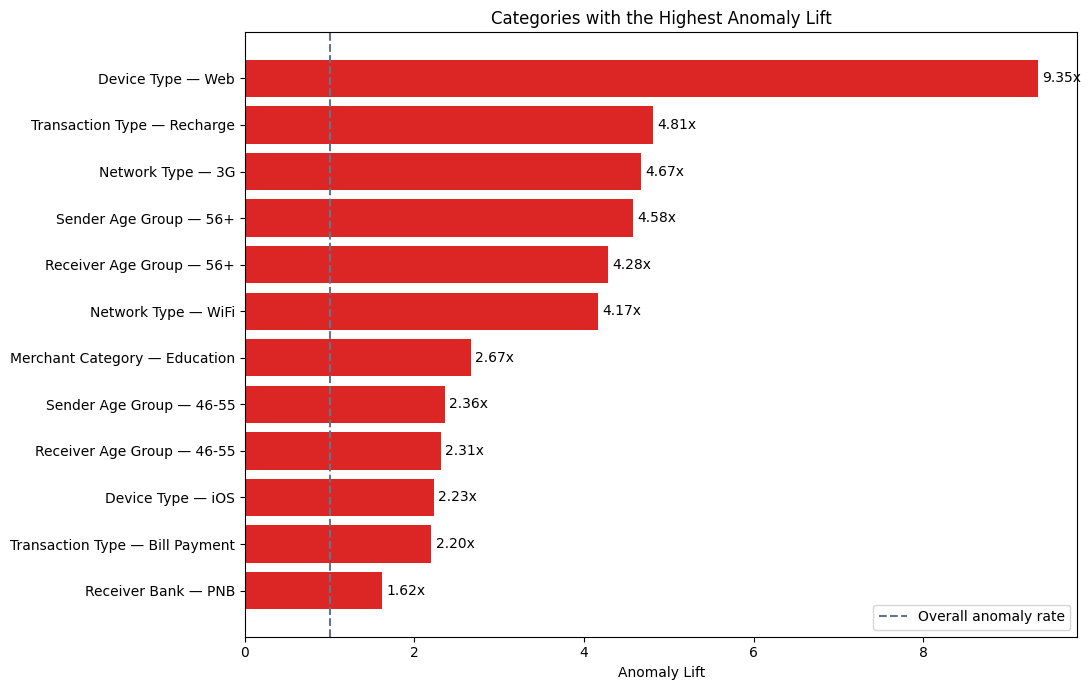

In [27]:
# Visualise the leading anomaly-lift categories
leading_categories = (
    categorical_anomaly_profile
    .query("total_transactions >= 500")
    .sort_values(
        "anomaly_lift",
        ascending=False
    )
    .head(12)
    .copy()
)

leading_categories["category_label"] = (
    leading_categories["dimension"]
    .str.replace("_", " ")
    .str.title()
    + " — "
    + leading_categories["category"].astype(str)
)

leading_categories = leading_categories.sort_values(
    "anomaly_lift",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    leading_categories["category_label"],
    leading_categories["anomaly_lift"],
    color="#DC2626"
)

plt.axvline(
    1,
    color="#64748B",
    linestyle="--",
    label="Overall anomaly rate"
)

plt.bar_label(
    bars,
    fmt="%.2fx",
    padding=3
)

plt.title("Categories with the Highest Anomaly Lift")
plt.xlabel("Anomaly Lift")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

## 9.15 Anomaly Results Export

### Purpose

The anomaly-detection results are exported into reusable files for operational analysis, database integration and future Power BI reporting.

Three analytical outputs are created:

1. A compact score file containing every transaction's anomaly result
2. A High-Anomaly investigation queue
3. A category-level anomaly profile

The trained Isolation Forest pipeline and model metadata are also stored so the experiment can be reproduced without retraining the model unnecessarily.

In [28]:
# Create export folders
processed_output_directory = Path(
    "../data/processed"
)

model_output_directory = Path(
    "../models"
)

processed_output_directory.mkdir(
    parents=True,
    exist_ok=True
)

model_output_directory.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Processed output directory:",
    processed_output_directory.resolve()
)

print(
    "Model output directory:",
    model_output_directory.resolve()
)

Processed output directory: C:\Users\kashv\Documents\UPI Transaction Operational Intelligence Platform\data\processed
Model output directory: C:\Users\kashv\Documents\UPI Transaction Operational Intelligence Platform\models


In [29]:
# Create the compact score output
anomaly_score_output = anomaly_data[
    [
        "transaction_id",
        "anomaly_score",
        "anomaly_risk_band",
        "is_anomaly"
    ]
].copy()

anomaly_score_output[
    "anomaly_risk_band"
] = anomaly_score_output[
    "anomaly_risk_band"
].astype(str)

anomaly_score_output[
    "model_version"
] = "isolation_forest_v1"

anomaly_score_output[
    "scored_at"
] = pd.Timestamp.now(tz="Asia/Kolkata")

anomaly_score_output.head()

,transaction_id,anomaly_score,anomaly_risk_band,is_anomaly,model_version,scored_at
0,TXN0000000001,0.4351,Normal,0,isolation_forest_v1,2026-08-14 07:37:56.452264+05:30
1,TXN0000000002,0.4617,Normal,0,isolation_forest_v1,2026-08-14 07:37:56.452264+05:30
2,TXN0000000003,0.4360,Normal,0,isolation_forest_v1,2026-08-14 07:37:56.452264+05:30
3,TXN0000000004,0.4575,Normal,0,isolation_forest_v1,2026-08-14 07:37:56.452264+05:30
4,TXN0000000005,0.4831,Normal,0,isolation_forest_v1,2026-08-14 07:37:56.452264+05:30


In [30]:
# Export analytical outputs
anomaly_scores_path = (
    processed_output_directory
    / "anomaly_scores.csv"
)

review_queue_path = (
    processed_output_directory
    / "high_anomaly_review_queue.csv"
)

category_profile_path = (
    processed_output_directory
    / "categorical_anomaly_profile.csv"
)

anomaly_score_output.to_csv(
    anomaly_scores_path,
    index=False
)

high_anomaly_review_queue.to_csv(
    review_queue_path,
    index=False
)

categorical_anomaly_profile.to_csv(
    category_profile_path,
    index=False
)

print("Exported:", anomaly_scores_path)
print("Exported:", review_queue_path)
print("Exported:", category_profile_path)

Exported: ..\data\processed\anomaly_scores.csv
Exported: ..\data\processed\high_anomaly_review_queue.csv
Exported: ..\data\processed\categorical_anomaly_profile.csv


In [31]:
# Save the trained pipeline
import joblib

model_path = (
    model_output_directory
    / "isolation_forest_pipeline.joblib"
)

joblib.dump(
    isolation_forest_pipeline,
    model_path
)

print("Saved model:", model_path)

Saved model: ..\models\isolation_forest_pipeline.joblib


In [32]:
# Save model metadata
import json

model_metadata = {
    "model_name": "Isolation Forest",
    "model_version": "isolation_forest_v1",
    "training_records": int(len(anomaly_data)),
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "monitor_threshold": float(monitor_threshold),
    "high_anomaly_threshold": float(
        high_anomaly_threshold
    ),
    "high_anomaly_percentage": float(
        anomaly_data["is_anomaly"].mean() * 100
    ),
    "score_interpretation": (
        "Higher anomaly_score means more unusual."
    ),
    "business_warning": (
        "Anomaly status does not confirm fraud or failure."
    )
}

metadata_path = (
    model_output_directory
    / "isolation_forest_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )

print("Saved metadata:", metadata_path)

Saved metadata: ..\models\isolation_forest_metadata.json


In [33]:
# Verify all outputs
export_verification = pd.DataFrame({
    "output": [
        "Anomaly scores",
        "High-anomaly review queue",
        "Categorical anomaly profile",
        "Isolation Forest model",
        "Model metadata"
    ],
    "path": [
        str(anomaly_scores_path),
        str(review_queue_path),
        str(category_profile_path),
        str(model_path),
        str(metadata_path)
    ],
    "exists": [
        anomaly_scores_path.exists(),
        review_queue_path.exists(),
        category_profile_path.exists(),
        model_path.exists(),
        metadata_path.exists()
    ],
    "records": [
        len(anomaly_score_output),
        len(high_anomaly_review_queue),
        len(categorical_anomaly_profile),
        None,
        None
    ]
})

export_verification

,output,path,exists,records
0,Anomaly scores,..\data\processed\anomaly_scores.csv,True,"250,000.0000"
1,High-anomaly review queue,..\data\processed\high_anomaly_review_queue.csv,True,"2,500.0000"
2,Categorical anomaly profile,..\data\processed\categorical_anomaly_profile.csv,True,57.0000
3,Isolation Forest model,..\models\isolation_forest_pipeline.joblib,True,NaN
4,Model metadata,..\models\isolation_forest_metadata.json,True,NaN
